Smother Experiment: comparing the influence of a die-off of coastal invertebrates and birds as a result of smothering from Bunker C whole oil to the water soluble fraction of PAH contamination only. Results are 3-day Atlantis output from 2019-2022

Half lives

| PAH Concentration	|	Naphthalene |	Phenanthrene | Pyrene |	Benzo(a)pyrene |
|-------------------|---------------|-----------------|--------|----------|
| Half life (secs)	|	259200 |	3628800	| 20476800	| 19353600 |
| Half life (days)	|	3	| 42 |	237 |	224 |

In [1]:
import os
import re
import xarray as xr
import numpy as np
import itertools
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.dates as mdates
from pathlib import Path
from datetime import timedelta
import matplotlib.pyplot as plt
import ssam_groups as groups

# Read in salish sea atlantis output files.
control_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Control/')
#control_paths = sorted([p for p in control_root.glob('v6719_60d/outputSalishSea.nc')])
control_paths = sorted([p for p in control_root.glob('highres-control-3y-*2/outputSalishSea.nc')])
for path in control_paths:
    print(path.parent.stem)

control_datasets = [xr.open_dataset(cfile,decode_cf=True) for cfile in control_paths]

In [2]:
control_file = "/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Control/v6719_60d/outputSalishSea.nc"
control = xr.open_dataset(str(control_file), decode_cf=True)
time = np.ma.filled(control.variables['t'])

In [3]:
scenario_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/Smother-test/')

In [4]:
# start and end time of data display, after burn-in
start = 0
end = 60

## All Scenarios

In [5]:
Turn_Point = [1, 2, 3, 4, 5, 8, 9, 33, 34, 37, 60, 66]
Active_Pass = [33, 60, 63]
English_Bay = [72, 74, 75, 80]
Jstrait = [1, 2] 

In [6]:
hex_colour = '#2F61A4' # alt #8CB7D7
hatches = ['oo', '///', 'xx', '++']

In [7]:
line_styles = itertools.cycle(('-', '--', '-.', ':'))#,(5, (10, 3)),
#    (0, (3, 1, 1, 1)),(0, (1, 1)),(0, (3, 10, 1, 10, 1, 10))))

In [9]:

scenario_paths = sorted([p for p in scenario_root.glob('6a_2019-07-16_t0*/outputSalishSea.nc')])
scenario_names = []
for path in scenario_paths:
    print(path.parent.stem)
    nm = str(path.parent.stem).split(sep='_')
    if nm[0] == '4a':
        scenario_loc = 'AP'
    elif nm[0] == '5b':
        scenario_loc = 'TP'
    elif nm[0] == '6a':
        scenario_loc = 'EB'
    elif nm[0] == '7a':
        scenario_loc = 'JF'
    scenario_names.append(scenario_loc+'-'+str(nm[1])+'-'+str(nm[2]))

6a_2019-07-16_t010
6a_2019-07-16_t010-AT
6a_2019-07-16_t02
6a_2019-07-16_t03
6a_2019-07-16_t04
6a_2019-07-16_t05
6a_2019-07-16_t07
6a_2019-07-16_t08
6a_2019-07-16_t09
6a_2019-07-16_t0ATdev


In [10]:
print(scenario_names)

['EB-2019-07-16-t010', 'EB-2019-07-16-t010-AT', 'EB-2019-07-16-t02', 'EB-2019-07-16-t03', 'EB-2019-07-16-t04', 'EB-2019-07-16-t05', 'EB-2019-07-16-t07', 'EB-2019-07-16-t08', 'EB-2019-07-16-t09', 'EB-2019-07-16-t0ATdev']


In [11]:
scenario_datasets = [xr.open_dataset(scen,decode_cf=True) for scen in scenario_paths]

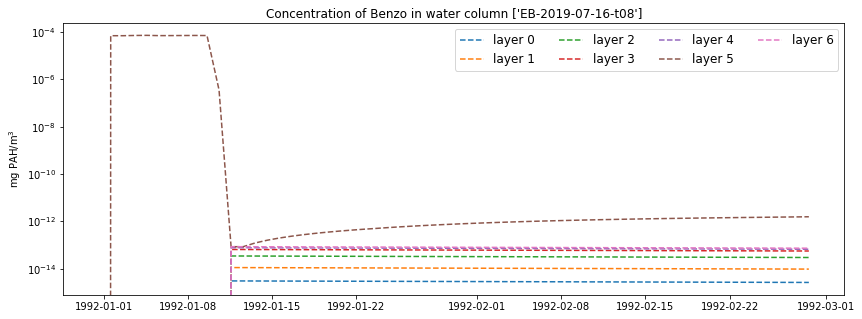

In [32]:
fig, ax = plt.subplots(figsize = (14,5))
for scenario, name in zip(scenario_datasets[5:6],scenario_names[5:6]):
    contam_tbl = scenario.variables['Benzo'][start:end,:,:]
    contam_t = contam_tbl.sum(axis=1)
    ax.semilogy(scenario.t[start:end], contam_t, linestyle=next(line_styles))
ax.set_title('Concentration of Benzo in water column '+str(scenario_names[5:6]), fontsize = 12)
ax.set_ylabel('mg PAH/m$^3$')
ax.legend(['layer 0', 'layer 1', 'layer 2', 'layer 3', 'layer 4', 'layer 5', 'layer 6'], fontsize=12, ncol=4); #loc='upper left', bbox_to_anchor=(1.05, 1), loc='upper center', 

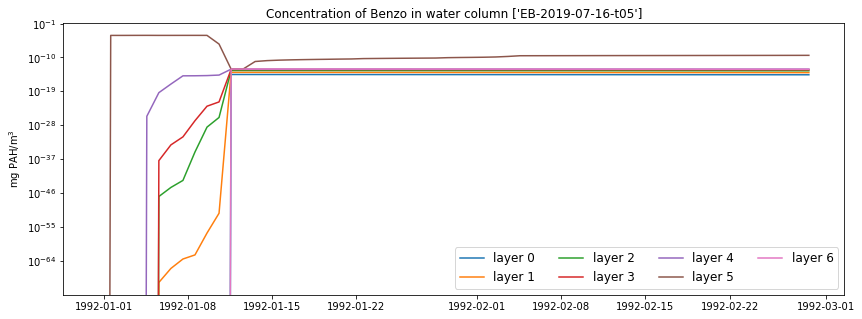

In [12]:
fig, ax = plt.subplots(figsize = (14,5))
for scenario, name in zip(scenario_datasets[9:10],scenario_names[9:10]):
    contam_tbl = scenario.variables['Benzo'][start:end,:,:]
    contam_t = contam_tbl.sum(axis=1)
    ax.semilogy(scenario.t[start:end], contam_t, linestyle=next(line_styles))
ax.set_title('Concentration of Benzo in water column '+str(scenario_names[5:6]), fontsize = 12)
ax.set_ylabel('mg PAH/m$^3$')
ax.legend(['layer 0', 'layer 1', 'layer 2', 'layer 3', 'layer 4', 'layer 5', 'layer 6'], fontsize=12, ncol=4); #loc='upper left', bbox_to_anchor=(1.05, 1), loc='upper center', 

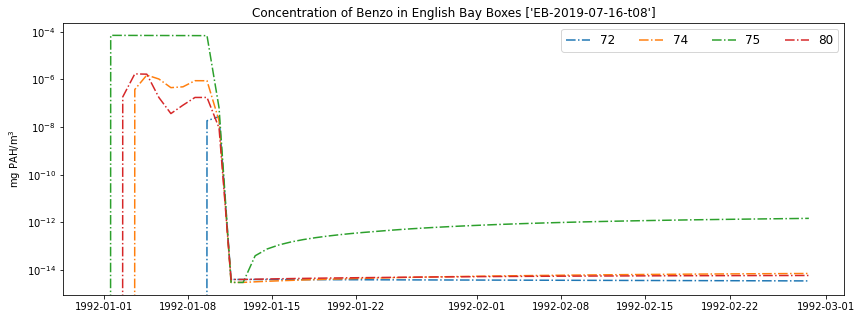

In [33]:
fig, ax = plt.subplots(figsize = (14,5))
for scenario, name in zip(scenario_datasets[5:6],scenario_names[5:6]):
    contam_tbl = scenario.variables['Benzo'][start:end,English_Bay,:]
    contam_t = contam_tbl.sum(axis=2)
    ax.semilogy(scenario.t[start:end], contam_t, linestyle=next(line_styles))
ax.set_title('Concentration of Benzo in English Bay Boxes '+str(scenario_names[5:6]), fontsize = 12)
ax.set_ylabel('mg PAH/m$^3$')
ax.legend(English_Bay, fontsize=12, ncol=4); #loc='upper left', bbox_to_anchor=(1.05, 1), loc='upper center', 

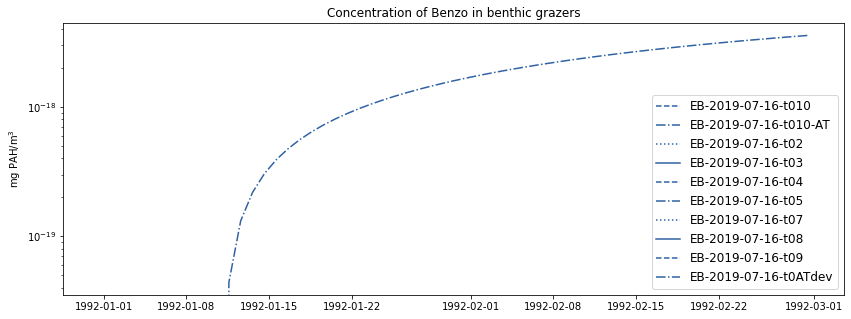

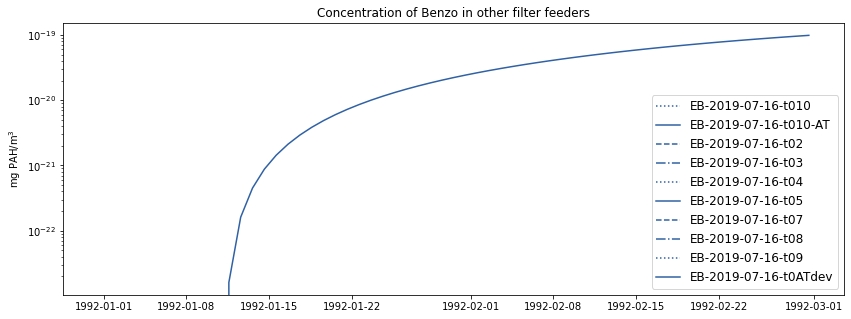

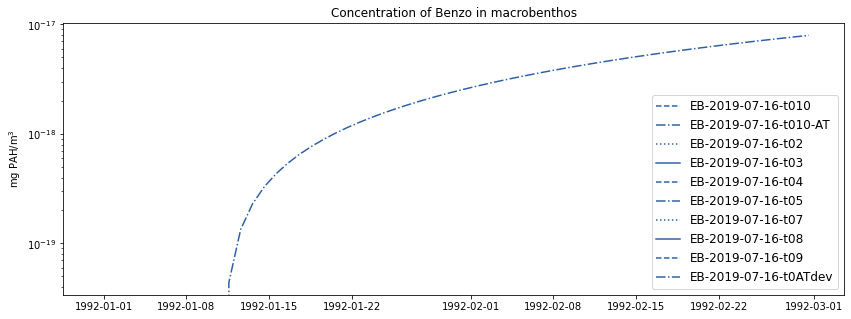

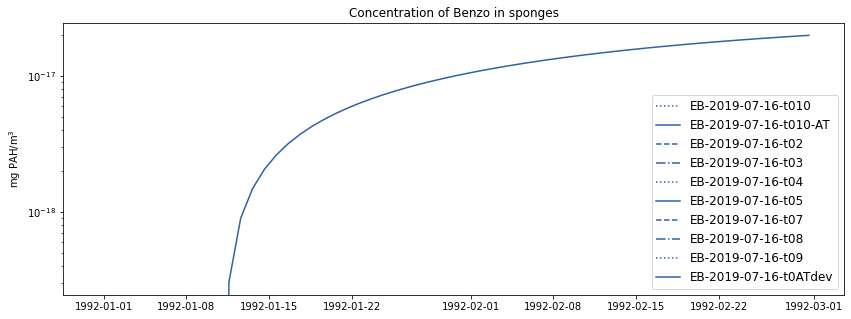

/home/rlovindeer/conda_envs/salishsea-tools/lib/python3.9/site-packages/matplotlib_inline/backend_inline.py:234: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  for label in axis.get_ticklabels()])


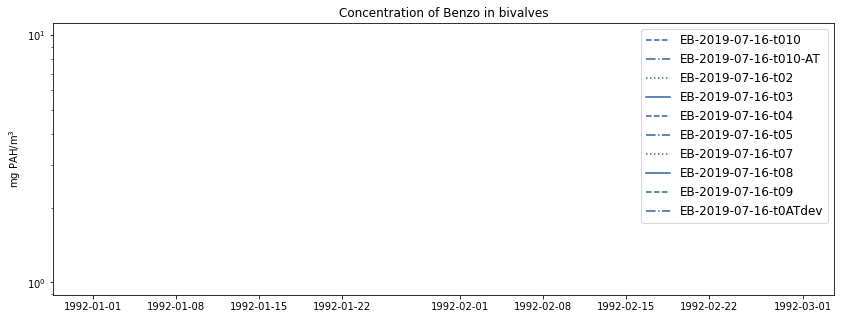

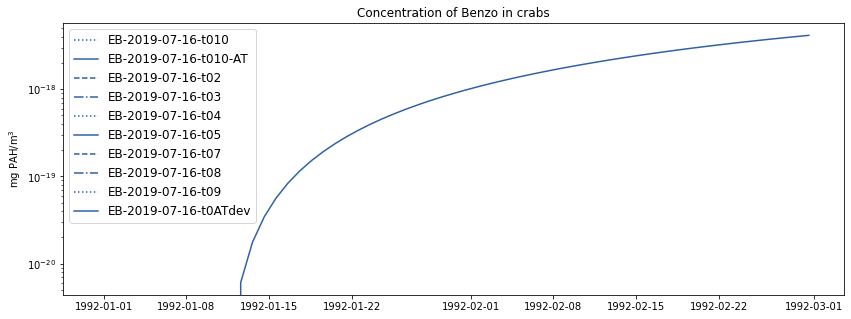

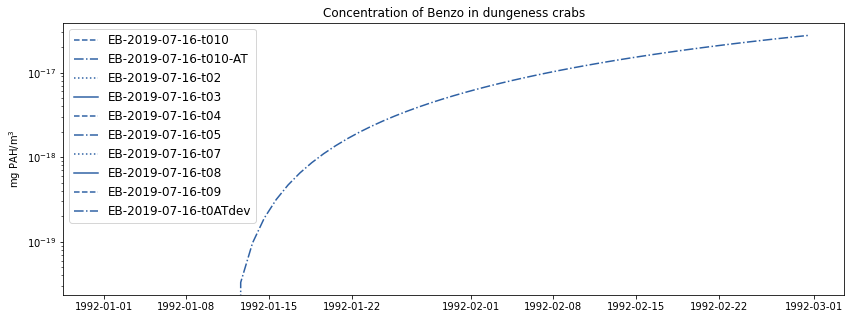

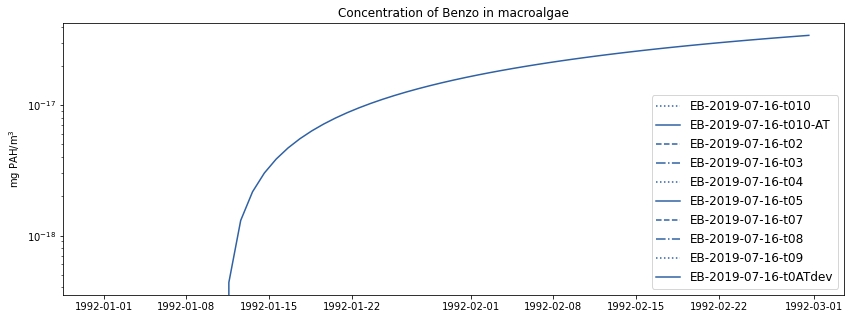

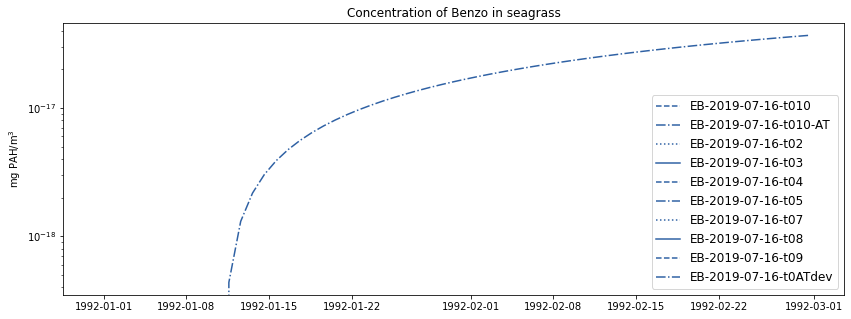

In [13]:
boxes = groups.salish_sea
for species in groups.benthos:
    fig, ax = plt.subplots(figsize = (14,5))
    for scenario, name in zip(scenario_datasets,scenario_names):
        contam_tb = scenario.variables[groups.benthos[species]+'_Benzo'][:,boxes]
        contam_t = contam_tb.sum(axis=(1))
        if 'AP' in name:
            hex_colour = '#863092'
        elif 'TP' in name:
            hex_colour = '#6DB48E'
        elif 'EB' in name:
            hex_colour = '#2F61A4'
        elif 'JF' in name:
            hex_colour = '#A27170'
        ax.semilogy(scenario.t, contam_t, color=hex_colour, linestyle=next(line_styles))
    ax.set_title('Concentration of Benzo in '+ species, fontsize = 12)
    ax.set_ylabel('mg PAH/m$^3$')
    ax.legend(scenario_names, fontsize=12, ncol=1);

In [14]:
def plot_benthic_biomass(bio_group, scenario_datasets, scenario_paths, control=control, boxes=groups.salish_sea, y_min=None, y_max=None):

    fig = plt.figure(figsize=(18, 18), facecolor='white')
    gs = plt.GridSpec(3, 3, wspace=0.2, hspace=0.2, width_ratios=[1,1,1], height_ratios=[1, 1, 1], )
    line_styles = itertools.cycle(('-', '--', '-.', ':',(5, (10, 3)),
    (0, (3, 1, 1, 1)),(0, (1, 1)),(0, (3, 10, 1, 10, 1, 10))))

    for species in bio_group:
        names = ['control']
        bio_index = (list(bio_group).index(species))
        if bio_index < 3:
            position = 0, bio_index
        elif bio_index > 5: 
            position = 2, bio_index-6
        else :
            position = 1, bio_index-3
        ax = fig.add_subplot(gs[position])

        pelagic_control = np.ma.filled(control.variables[bio_group[species] + '_N'][:,boxes], np.nan)
        pelagic_control = pelagic_control.sum(axis=1)
        ax.plot(control.t, pelagic_control, 'k')
    
        for scenario, path in zip(scenario_datasets, scenario_paths):
            nm = str(path.parent.stem).split(sep='_')
            scenario_name = 'EB-'+nm[2]  
            names.append(scenario_name)

            pelagic_oiled = np.ma.filled(scenario.variables[bio_group[species] + '_N'][:,boxes], np.nan) # tonnes
            pelagic_oiled = pelagic_oiled.sum(axis=1) 
            ax.plot(scenario.t, pelagic_oiled, linewidth = 2, linestyle=next(line_styles),) #color=hex_colour,linestyle=next(line_styles)
        
        ax.set_ylabel('Biomass', fontsize=12)
        ax.set_title(species)
        ax.set_ylim([y_min, y_max])
    ax.legend(names, fontsize=12); #bbox_to_anchor=(1.05, 1)

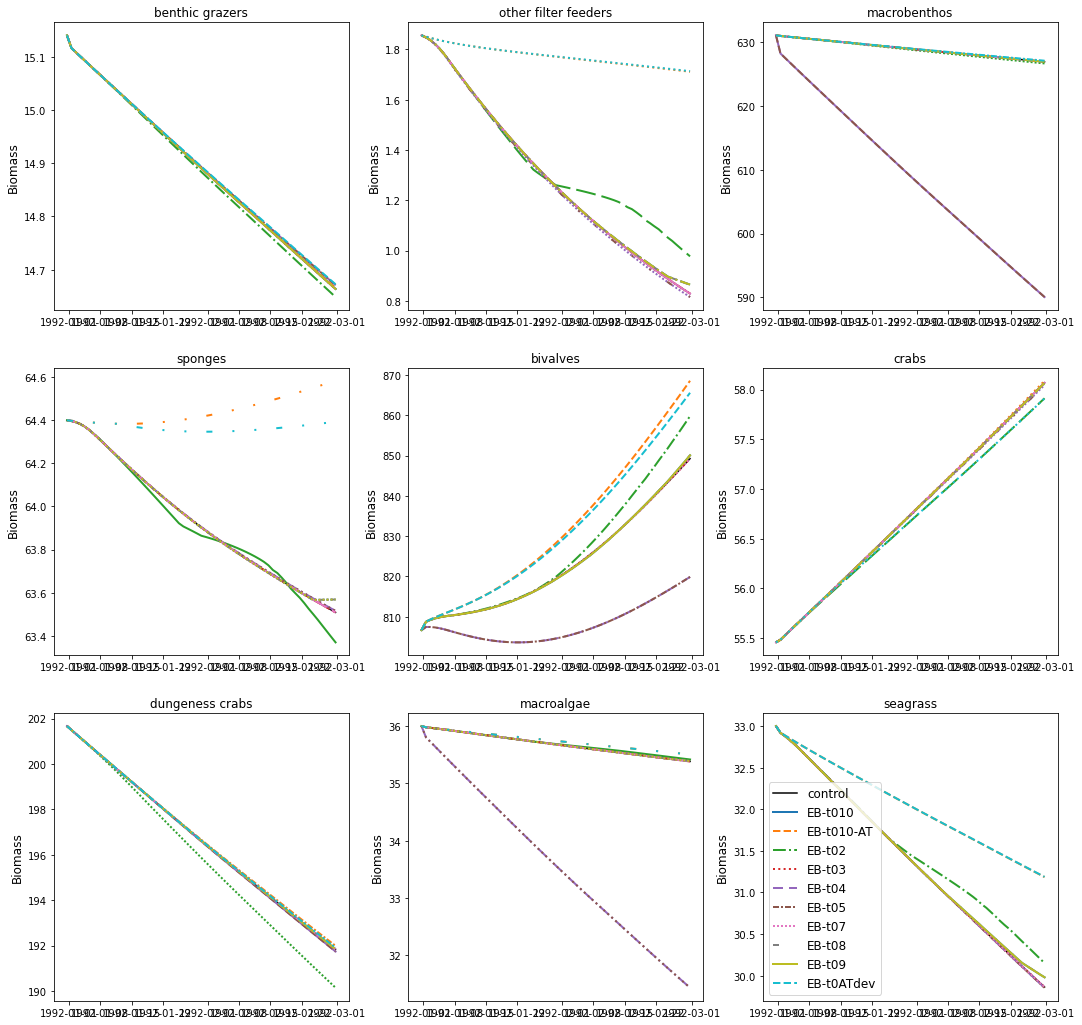

In [15]:
plot_benthic_biomass(groups.benthos, scenario_datasets, scenario_paths, boxes=English_Bay)

In [17]:
def plot_vert_biomass(bio_group, scenario_datasets=scenario_datasets, scenario_paths=scenario_paths, control=control, boxes=groups.salish_sea, y_min=None, y_max=None):

    fig = plt.figure(figsize=(18, 18), facecolor='white')
    gs = plt.GridSpec(3, 3, wspace=0.2, hspace=0.2, width_ratios=[1,1,1], height_ratios=[1, 1, 1], )
    line_styles = itertools.cycle(('-', '--', '-.', ':',(5, (10, 3)),
    (0, (3, 1, 1, 1)),(0, (1, 1)),(0, (3, 10, 1, 10, 1, 10))))

    for species in bio_group:
        names = ['control']
        bio_index = (list(bio_group).index(species))
        if bio_index < 3:
            position = 0, bio_index
        elif bio_index > 5: 
            position = 2, bio_index-6
        else :
            position = 1, bio_index-3
        ax = fig.add_subplot(gs[position])

        numCohorts = groups.cohorts[bio_group[species]]
        
        for scenario, path in zip(scenario_datasets, scenario_paths):
            nm = str(path.parent.stem).split(sep='_')
            scenario_name = 'EB-'+nm[2]  
            names.append(scenario_name)

            for cohort in range (1, numCohorts+1):

                new_species = bio_group[species] + str(cohort)
                    #this_linestyle=next(line_styles)
            
                o_numbers_tbl = np.ma.filled(scenario.variables[new_species + '_Nums'][:, boxes, 0:6], np.nan)
                o_structuralN_tbl = np.ma.filled(scenario.variables[new_species +'_StructN'][:, boxes, 0:6], np.nan)
                o_reservedN_tbl = np.ma.filled(scenario.variables[new_species +'_ResN'][:, boxes, 0:6], np.nan)

                c_numbers_tbl = np.ma.filled(control.variables[new_species + '_Nums'][:, boxes, 0:6], np.nan)
                c_structuralN_tbl = np.ma.filled(control.variables[new_species +'_StructN'][:, boxes, 0:6], np.nan)
                c_reservedN_tbl = np.ma.filled(control.variables[new_species +'_ResN'][:, boxes, 0:6], np.nan)

                o_weightatage_tbl = (o_structuralN_tbl + o_reservedN_tbl) * o_numbers_tbl 
                o_weightatage = o_weightatage_tbl.sum(axis=(1,2))

                c_weightatage_tbl = (c_structuralN_tbl + c_reservedN_tbl) * c_numbers_tbl 
                c_weightatage = c_weightatage_tbl.sum(axis=(1,2))

                ax.plot(control.t, c_weightatage, linewidth = 2, color='black') #, label='control-'+scenario_name)
                ax.plot(scenario.t, o_weightatage, linewidth = 2, linestyle=':') #label=scenario_name, 
        ax.set_title(species)
        plt.ylabel('Biomass', fontsize=12)
        ax.set_ylim([y_min, y_max])
    ax.legend(names, fontsize=12, bbox_to_anchor=(1.05, 1)) #, loc='lower right'

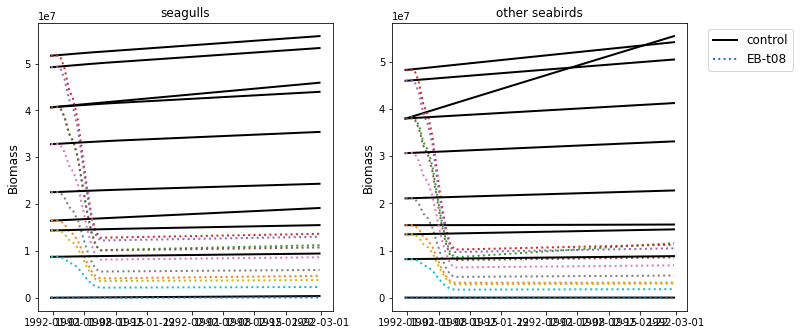

In [20]:
# EB-t08 is benzo impact on v6719
plot_vert_biomass(groups.birds, scenario_datasets[7:8], scenario_paths[7:8])

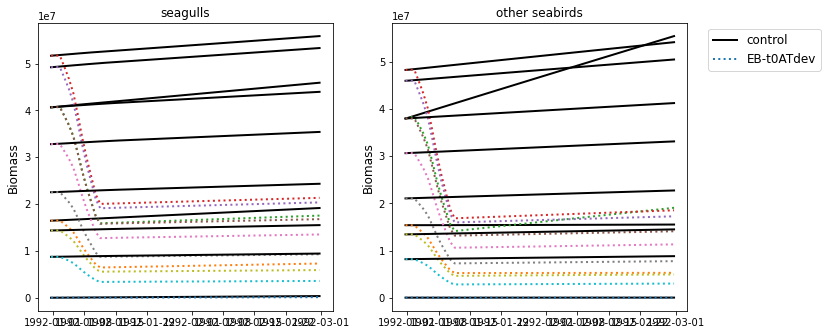

In [18]:
# Benzo impact on version AtlantisTrunk Dev on Github - only version where benthos takes in contaminants
plot_vert_biomass(groups.birds, scenario_datasets[9:10], scenario_paths[9:10])

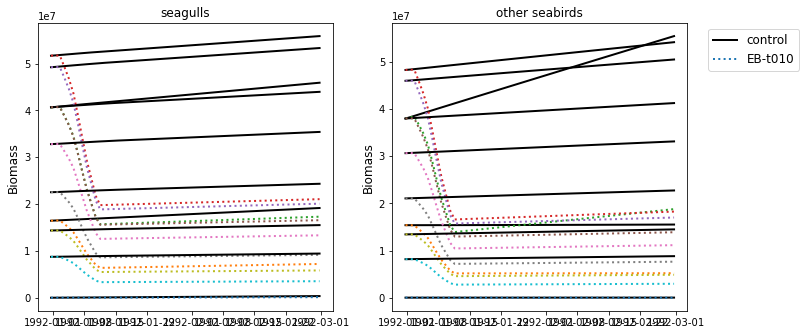

In [21]:
# Benzo impact on version 6721
plot_vert_biomass(groups.birds, scenario_datasets[1:2], scenario_paths[1:2])

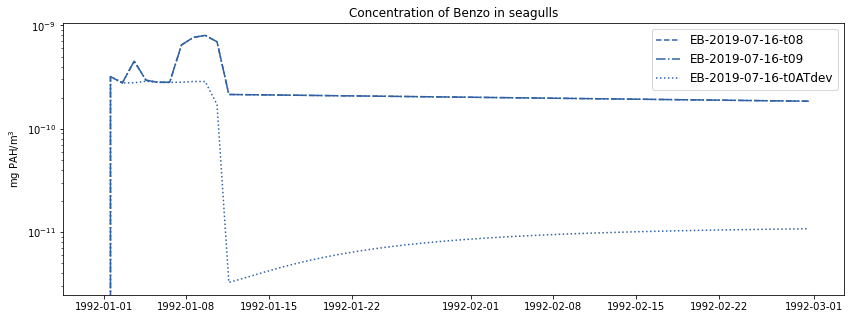

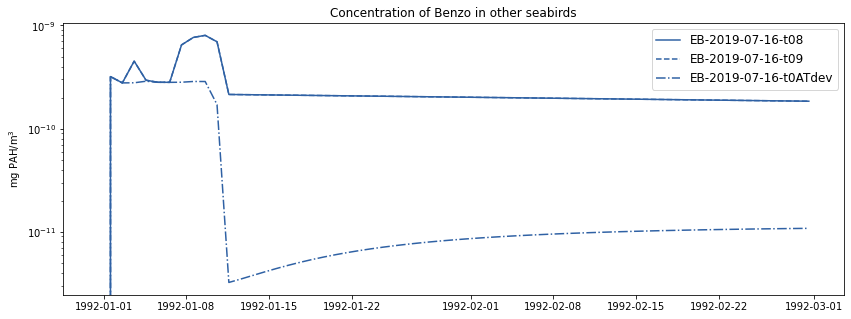

In [20]:
boxes = groups.salish_sea
for species in groups.birds:
    fig, ax = plt.subplots(figsize = (14,5))
    for scenario, name in zip(scenario_datasets[7:10],scenario_names[7:10]):
        contam_tbl = 0
        for cohort in range (1, groups.cohorts[groups.birds[species]]+1):
            contam_tbl = contam_tbl + scenario.variables[groups.birds[species]+str(cohort)+'_Benzo'][:,boxes,0:6]
        contam_t = contam_tbl.sum(axis=(1,2))
        if 'AP' in name:
            hex_colour = '#863092'
        elif 'TP' in name:
            hex_colour = '#6DB48E'
        elif 'EB' in name:
            hex_colour = '#2F61A4'
        elif 'JF' in name:
            hex_colour = '#A27170'
        ax.semilogy(scenario.t, contam_t, color=hex_colour, linestyle=next(line_styles))
    ax.set_title('Concentration of Benzo in '+ species, fontsize = 12)
    ax.set_ylabel('mg PAH/m$^3$')
    ax.legend(scenario_names[7:10], fontsize=12, ncol=1);